# Smartphone-Based Recognition of Human Activities and Postural Transitions
## CNN-LSTM (hybrid) model: TensorFlow / Keras

**Dataset:** UCI HAPT (Smartphone-Based Recognition of Human Activities and Postural Transitions): 30 volunteers, Samsung Galaxy S II on the waist, accelerometer and gyroscope at **50 Hz**, **12 classes** (6 basic activities and 6 postural transitions).

**Pipeline**

1. Load raw tri-axial accelerometer and gyroscope signals (`RawData/`)
2. Preprocess: median filter and 20 Hz Butterworth low-pass (noise filtering)
3. Segment into sliding windows of **128 samples (2.56 s) × 6 channels**
4. **Subject-wise** split: 70 % train / 15 % validation / 15 % test
5. Z-score normalisation, fitted on the training set only
6. CNN-LSTM: Conv1D blocks extract local motion features, and stacked LSTMs model how they change over time
7. Evaluation: accuracy, precision, recall, F1, ROC-AUC, confusion matrix, learning curves, and computational cost

## 1. Setup

In [1]:
# On Google Colab, TensorFlow is already installed. Locally run:
# pip install tensorflow scikit-learn scipy pandas matplotlib seaborn

import os, glob, json, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt, medfilt
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             classification_report, confusion_matrix, roc_auc_score)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Get the dataset into Colab

Pick **one** option and run only that cell. Both unzip the dataset into `/content/hapt`.

* **Option A: Google Drive (recommended).** Upload the zip file, unchanged, to *My Drive*, then run the Option A cell and allow access.
* **Option B: upload from your computer.** Run the Option B cell and choose the zip. It is about 80 MB, so this takes a few minutes, and you have to repeat it every time Colab restarts.

In [3]:
# ---- Option A: from Google Drive ----
from google.colab import drive
drive.mount('/content/drive')
!ls "/content/drive/MyDrive/HAPT Data Set"

Mounted at /content/drive
smartphone+based+recognition+of+human+activities+and+postural+transitions.zip


In [17]:
# Unzip the dataset from Google Drive to /content/hapt
!unzip -oq "/content/drive/MyDrive/HAPT Data Set/smartphone+based+recognition+of+human+activities+and+postural+transitions.zip" -d /content/hapt
!ls /content/hapt

activity_labels.txt  features.txt  README.txt  Train
features_info.txt    RawData	   Test


In [ ]:
# ---- Option B: upload the zip from your computer ----
# from google.colab import files
# uploaded = files.upload()                  # choose the zip in the dialog
# zip_name = list(uploaded.keys())[0]
# !unzip -oq "{zip_name}" -d /content/hapt
# !ls /content/hapt

## 3. Configuration

In [6]:
DATA_DIR = "/content/hapt"    # the notebook finds RawData/ inside this folder

FS          = 50      # sampling rate (Hz)
WINDOW      = 128     # samples per window (2.56 s)
STEP_BASIC  = 64      # 50 % overlap for the 6 basic activities
STEP_TRANS  = 16      # denser overlap for the short, rare transition segments
N_CHANNELS  = 6       # acc x,y,z + gyro x,y,z

BATCH_SIZE  = 64
EPOCHS      = 80      # EarlyStopping will usually stop well before this
LR          = 1e-3

OUT_DIR = "/content/outputs"
os.makedirs(OUT_DIR, exist_ok=True)

## 4. Load the raw data

In [7]:
def find_rawdata_dir(root):
    hits = glob.glob(os.path.join(root, "**", "labels.txt"), recursive=True)
    hits = [h for h in hits if glob.glob(os.path.join(os.path.dirname(h), "acc_exp*_user*.txt"))]
    if not hits:
        raise FileNotFoundError(
            f"Couldn't find RawData/labels.txt under '{root}'. "
            "Make sure you downloaded the full UCI HAPT zip (it contains a RawData folder).")
    return os.path.dirname(hits[0])

RAW_DIR = find_rawdata_dir(DATA_DIR)
print("RawData folder:", RAW_DIR)

# activity_labels.txt normally sits one level above RawData
act_file = glob.glob(os.path.join(os.path.dirname(RAW_DIR), "activity_labels.txt")) + \
           glob.glob(os.path.join(RAW_DIR, "activity_labels.txt"))
if act_file:
    act = pd.read_csv(act_file[0], sep=r"\s+", header=None, names=["id", "name"])
    ACTIVITY_NAMES = dict(zip(act.id, act.name))
else:
    ACTIVITY_NAMES = {1:"WALKING", 2:"WALKING_UPSTAIRS", 3:"WALKING_DOWNSTAIRS", 4:"SITTING",
                      5:"STANDING", 6:"LAYING", 7:"STAND_TO_SIT", 8:"SIT_TO_STAND",
                      9:"SIT_TO_LIE", 10:"LIE_TO_SIT", 11:"STAND_TO_LIE", 12:"LIE_TO_STAND"}
CLASS_NAMES = [ACTIVITY_NAMES[i] for i in range(1, 13)]
TRANSITIONS = set(range(7, 13))

# labels.txt columns: experiment, user, activity, start sample, end sample
labels = pd.read_csv(os.path.join(RAW_DIR, "labels.txt"), sep=r"\s+", header=None,
                     names=["exp", "user", "activity", "start", "end"])
print(labels.shape)
labels.head()

RawData folder: /content/hapt/RawData
(1214, 5)


,exp,user,activity,start,end
0,1,1,5,250,1232
1,1,1,7,1233,1392
2,1,1,4,1393,2194
3,1,1,8,2195,2359
4,1,1,5,2360,3374


In [8]:
def load_experiment(exp, user):
    acc  = np.loadtxt(os.path.join(RAW_DIR, f"acc_exp{exp:02d}_user{user:02d}.txt"))
    gyro = np.loadtxt(os.path.join(RAW_DIR, f"gyro_exp{exp:02d}_user{user:02d}.txt"))
    n = min(len(acc), len(gyro))
    return np.hstack([acc[:n], gyro[:n]]).astype(np.float32)   # (T, 6)

experiments = labels[["exp", "user"]].drop_duplicates().values
raw = {(e, u): load_experiment(e, u) for e, u in experiments}
print(f"Loaded {len(raw)} experiment recordings from {labels.user.nunique()} users")

Loaded 61 experiment recordings from 30 users


## 5. Preprocessing: noise filtering

Following the original dataset paper: a **median filter** (kernel 3) removes spikes, then a **3rd-order Butterworth low-pass at 20 Hz** removes high-frequency noise. Human movement is almost entirely below 20 Hz.

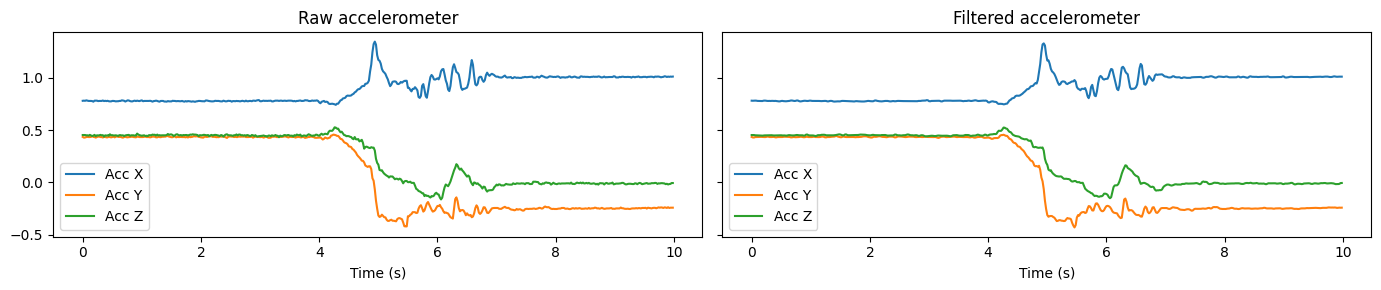

In [9]:
b, a = butter(N=3, Wn=20 / (FS / 2), btype="low")

def denoise(sig):
    out = np.empty_like(sig)
    for c in range(sig.shape[1]):
        out[:, c] = filtfilt(b, a, medfilt(sig[:, c], kernel_size=3))
    return out

filtered = {k: denoise(v) for k, v in raw.items()}

# quick visual check
k0 = next(iter(filtered))
fig, ax = plt.subplots(1, 2, figsize=(14, 3), sharey=True)
t = np.arange(500) / FS
for c, name in enumerate(["Acc X", "Acc Y", "Acc Z"]):
    ax[0].plot(t, raw[k0][2000:2500, c], label=name)
    ax[1].plot(t, filtered[k0][2000:2500, c], label=name)
ax[0].set_title("Raw accelerometer"); ax[1].set_title("Filtered accelerometer")
for a_ in ax: a_.set_xlabel("Time (s)"); a_.legend()
plt.tight_layout(); plt.show()

## 6. Windowing: 128 × 6 input sequences

Each labelled segment in `labels.txt` is cut into fixed-length windows.

* **Basic activities:** step 64 (50 % overlap)
* **Transitions:** these last only about 2–5 s, so a step of 16 gives more samples from the rare classes.
* A transition segment **shorter than 128 samples** is not thrown away. A single window is taken centred on it.

Labels are converted to 0–11 for Keras.

X: (12005, 128, 6)  y: (12005,)


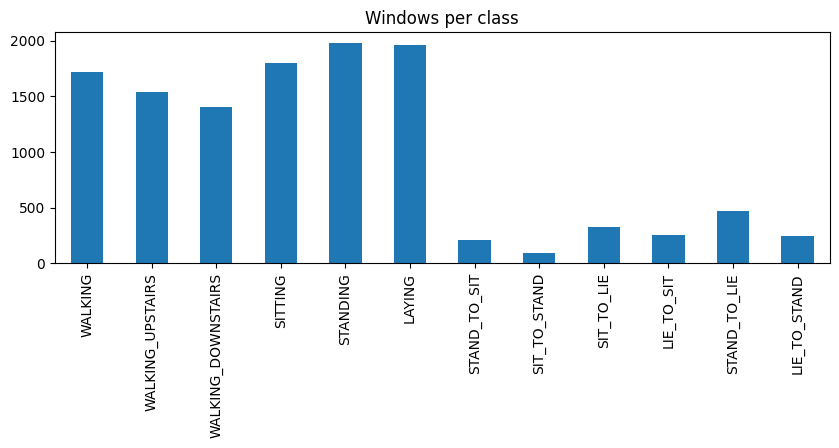

In [10]:
def make_windows(labels_df, signals):
    X, y, subj = [], [], []
    for _, r in labels_df.iterrows():
        sig = signals[(r.exp, r.user)]
        start, end = int(r.start) - 1, int(r.end)          # labels are 1-based, inclusive
        length = end - start
        step = STEP_TRANS if r.activity in TRANSITIONS else STEP_BASIC

        if length >= WINDOW:
            starts = range(start, end - WINDOW + 1, step)
        else:                                               # short transition: centre a window on it
            c = start + length // 2
            s = int(np.clip(c - WINDOW // 2, 0, len(sig) - WINDOW))
            starts = [s]

        for s in starts:
            X.append(sig[s:s + WINDOW])
            y.append(r.activity - 1)
            subj.append(r.user)
    return np.stack(X), np.array(y), np.array(subj)

X_all, y_all, subj_all = make_windows(labels, filtered)
print("X:", X_all.shape, " y:", y_all.shape)

counts = pd.Series(y_all).value_counts().sort_index()
counts.index = CLASS_NAMES
counts.plot.bar(figsize=(10, 3), title="Windows per class"); plt.show()

## 7. Dataset split: subject-wise 70 / 15 / 15

The split is by **volunteer**, not by window. Overlapping windows from the same person are nearly identical, so a random split leaks test data into training and inflates accuracy. With a subject-wise split, the test score measures how well the model **generalises to people it has never seen**.

In [11]:
users = np.unique(subj_all)
rng = np.random.default_rng(SEED)
rng.shuffle(users)

n_train = int(round(0.70 * len(users)))
n_val   = int(round(0.15 * len(users)))
train_users = users[:n_train]
val_users   = users[n_train:n_train + n_val]
test_users  = users[n_train + n_val:]

tr = np.isin(subj_all, train_users)
va = np.isin(subj_all, val_users)
te = np.isin(subj_all, test_users)

X_train, y_train = X_all[tr], y_all[tr]
X_val,   y_val   = X_all[va], y_all[va]
X_test,  y_test  = X_all[te], y_all[te]

print("Train users:", sorted(train_users.tolist()))
print("Val users:  ", sorted(val_users.tolist()))
print("Test users: ", sorted(test_users.tolist()))
print(f"Windows  train={len(X_train)}  val={len(X_val)}  test={len(X_test)}")

# Save the split so the MLP / CNN / LSTM models use exactly the same data
np.savez_compressed(os.path.join(OUT_DIR, "split_users.npz"),
                    train=train_users, val=val_users, test=test_users)

Train users: [1, 4, 6, 7, 8, 10, 11, 13, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 30]
Val users:   [3, 12, 15, 29]
Test users:  [2, 5, 9, 14, 28]
Windows  train=8583  val=1536  test=1886


## 8. Normalisation (z-score, per channel, fitted on the training set only)

In [12]:
mu  = X_train.reshape(-1, N_CHANNELS).mean(axis=0)
std = X_train.reshape(-1, N_CHANNELS).std(axis=0) + 1e-8

X_train = (X_train - mu) / std
X_val   = (X_val   - mu) / std
X_test  = (X_test  - mu) / std

np.savez(os.path.join(OUT_DIR, "norm_stats.npz"), mu=mu, std=std)
print("Channel means (train, after):", X_train.reshape(-1, 6).mean(0).round(3))

Channel means (train, after): [ 0.003  0.     0.     0.    -0.    -0.   ]


## 9. CNN-LSTM model

```
Input (128 × 6)
 → Conv1D(64, k=5) + BN + ReLU
 → Conv1D(64, k=5) + BN + ReLU → MaxPool(2) → Dropout
 → Conv1D(128, k=3) + BN + ReLU → MaxPool(2) → Dropout      # CNN = local feature extraction  (32 × 128)
 → LSTM(128, return_sequences) → LSTM(64)                   # LSTM = temporal dependencies
 → Dropout → Dense(64, ReLU) → Dense(12, softmax)
```

The convolutions pick out short motion patterns such as a step, a sit-down impulse or a rotation. Pooling shortens the sequence from 128 to 32 time steps, which makes the LSTM faster. The LSTM then models the **order** of those patterns, which is what tells apart transitions like *sit→stand* and *stand→sit*.

In [13]:
def build_cnn_lstm(input_shape=(WINDOW, N_CHANNELS), n_classes=12):
    inp = keras.Input(shape=input_shape, name="sensor_window")

    x = layers.Conv1D(64, 5, padding="same")(inp)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Conv1D(64, 5, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv1D(128, 3, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.LSTM(128, return_sequences=True)(x)
    x = layers.LSTM(64)(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(n_classes, activation="softmax", name="activity")(x)
    return keras.Model(inp, out, name="CNN_LSTM")

model = build_cnn_lstm()
model.compile(optimizer=keras.optimizers.Adam(LR),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sensor_window (InputLayer)      │ (None, 128, 6)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 128, 64)        │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 128, 64)        │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 64, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activity (Dense)                │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 234,188 (914.80 KB)

 Trainable params: 233,676 (912.80 KB)

 Non-trainable params: 512 (2.00 KB)

## 10. Training

* **Class weights:** transitions make up only a few percent of the windows. Without weighting, the model would mostly ignore them.
* **EarlyStopping** on validation loss restores the best weights.
* **ReduceLROnPlateau** halves the learning rate when validation loss stops improving.

In [14]:
cw = compute_class_weight("balanced", classes=np.arange(12), y=y_train)
class_weight = dict(enumerate(cw))
print({CLASS_NAMES[k]: round(float(v), 2) for k, v in class_weight.items()})

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5),
    keras.callbacks.ModelCheckpoint(os.path.join(OUT_DIR, "cnn_lstm_best.keras"),
                                    monitor="val_loss", save_best_only=True),
]

t0 = time.time()
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=EPOCHS, batch_size=BATCH_SIZE,
                    class_weight=class_weight,
                    callbacks=callbacks, verbose=2)
train_time = time.time() - t0
print(f"Training time: {train_time:.1f} s  ({len(history.history['loss'])} epochs)")

{'WALKING': 0.58, 'WALKING_UPSTAIRS': 0.66, 'WALKING_DOWNSTAIRS': 0.72, 'SITTING': 0.55, 'STANDING': 0.5, 'LAYING': 0.51, 'STAND_TO_SIT': 5.07, 'SIT_TO_STAND': 10.52, 'SIT_TO_LIE': 3.1, 'LIE_TO_SIT': 4.0, 'STAND_TO_LIE': 2.14, 'LIE_TO_STAND': 4.02}
Epoch 1/80
135/135 - 12s - 87ms/step - accuracy: 0.6887 - loss: 1.1621 - val_accuracy: 0.8444 - val_loss: 0.4371 - learning_rate: 0.0010
Epoch 2/80
135/135 - 2s - 14ms/step - accuracy: 0.8526 - loss: 0.5682 - val_accuracy: 0.9251 - val_loss: 0.2174 - learning_rate: 0.0010
Epoch 3/80
135/135 - 2s - 14ms/step - accuracy: 0.8998 - loss: 0.4235 - val_accuracy: 0.9108 - val_loss: 0.2851 - learning_rate: 0.0010
Epoch 4/80
135/135 - 2s - 17ms/step - accuracy: 0.9015 - loss: 0.3789 - val_accuracy: 0.9004 - val_loss: 0.3143 - learning_rate: 0.0010
Epoch 5/80
135/135 - 3s - 20ms/step - accuracy: 0.9111 - loss: 0.3414 - val_accuracy: 0.9388 - val_loss: 0.1692 - learning_rate: 0.0010
Epoch 6/80
135/135 - 2s - 14ms/step - accuracy: 0.9205 - loss: 0.3125 

## 11. Training / validation curves

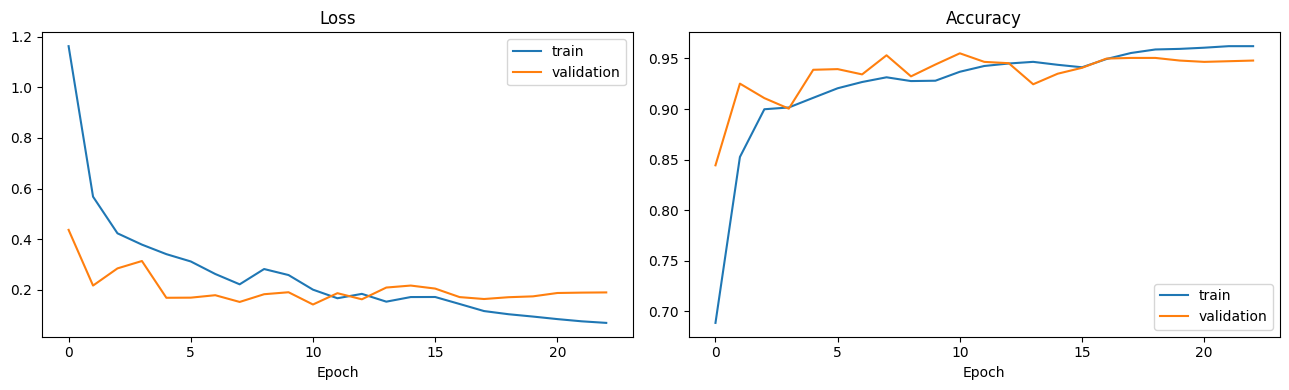

In [15]:
h = history.history
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(h["loss"], label="train"); ax[0].plot(h["val_loss"], label="validation")
ax[0].set_title("Loss"); ax[0].set_xlabel("Epoch"); ax[0].legend()
ax[1].plot(h["accuracy"], label="train"); ax[1].plot(h["val_accuracy"], label="validation")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("Epoch"); ax[1].legend()
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "cnn_lstm_curves.png"), dpi=150); plt.show()

## 12. Evaluation on the unseen test subjects

In [18]:
y_prob = model.predict(X_test, batch_size=256, verbose=0)
y_pred = y_prob.argmax(axis=1)

present = np.unique(y_test)   # guard in case a class is missing from the test users
metrics = {
    "accuracy":           accuracy_score(y_test, y_pred),
    "precision_macro":    precision_score(y_test, y_pred, average="macro", zero_division=0),
    "recall_macro":       recall_score(y_test, y_pred, average="macro", zero_division=0),
    "f1_macro":           f1_score(y_test, y_pred, average="macro", zero_division=0),
    "f1_weighted":        f1_score(y_test, y_pred, average="weighted", zero_division=0),
    "roc_auc_macro_ovr":  roc_auc_score(y_test, y_prob[:, present] / y_prob[:, present].sum(1, keepdims=True),
                                        multi_class="ovr", average="macro", labels=present),
}
for k, v in metrics.items():
    print(f"{k:20s}: {v:.4f}")

print("\n", classification_report(y_test, y_pred, labels=np.arange(12),
                                  target_names=CLASS_NAMES, digits=3, zero_division=0))

accuracy            : 0.8378
precision_macro     : 0.8374
recall_macro        : 0.8289
f1_macro            : 0.8314
f1_weighted         : 0.8376
roc_auc_macro_ovr   : 0.9889

                     precision    recall  f1-score   support

           WALKING      0.976     0.868     0.919       280
  WALKING_UPSTAIRS      0.863     0.988     0.921       249
WALKING_DOWNSTAIRS      0.987     0.978     0.982       227
           SITTING      0.651     0.632     0.642       269
          STANDING      0.695     0.693     0.694       303
            LAYING      0.975     0.989     0.982       281
      STAND_TO_SIT      0.925     0.841     0.881        44
      SIT_TO_STAND      1.000     0.900     0.947        10
        SIT_TO_LIE      0.583     0.724     0.646        58
        LIE_TO_SIT      0.846     0.846     0.846        39
      STAND_TO_LIE      0.722     0.663     0.691        86
      LIE_TO_STAND      0.825     0.825     0.825        40

          accuracy                        

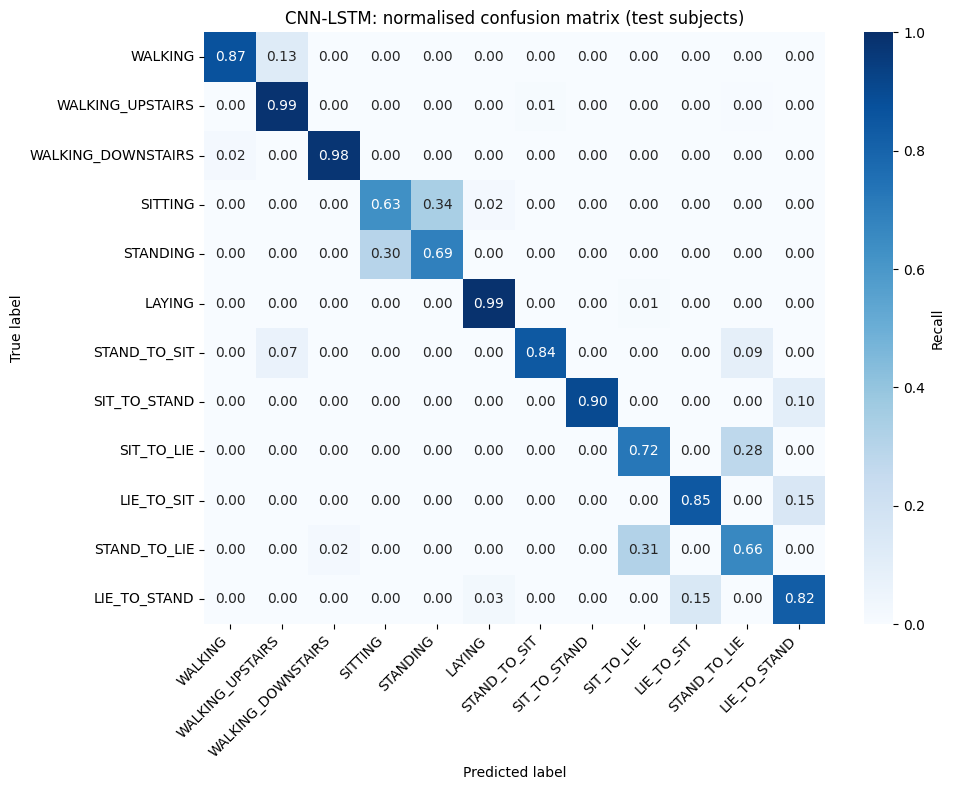

Accuracy on basic activities : 0.8508
Accuracy on transitions      : 0.7617


In [19]:
cm = confusion_matrix(y_test, y_pred, labels=np.arange(12), normalize="true")
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES, vmin=0, vmax=1, cbar_kws={"label": "Recall"})
plt.xlabel("Predicted label"); plt.ylabel("True label")
plt.title("CNN-LSTM: normalised confusion matrix (test subjects)")
plt.xticks(rotation=45, ha="right"); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "cnn_lstm_confusion.png"), dpi=150); plt.show()

# Basic activities vs transitions
basic = y_test < 6
print(f"Accuracy on basic activities : {accuracy_score(y_test[basic], y_pred[basic]):.4f}")
print(f"Accuracy on transitions      : {accuracy_score(y_test[~basic], y_pred[~basic]):.4f}")

In [20]:
y_prob = model.predict(X_test, batch_size=256, verbose=0)
y_pred = y_prob.argmax(axis=1)

present = np.unique(y_test)   # guard in case a class is missing from the test users
metrics = {
    "accuracy":           accuracy_score(y_test, y_pred),
    "precision_macro":    precision_score(y_test, y_pred, average="macro", zero_division=0),
    "recall_macro":       recall_score(y_test, y_pred, average="macro", zero_division=0),
    "f1_macro":           f1_score(y_test, y_pred, average="macro", zero_division=0),
    "f1_weighted":        f1_score(y_test, y_pred, average="weighted", zero_division=0),
    "roc_auc_macro_ovr":  roc_auc_score(y_test, y_prob[:, present] / y_prob[:, present].sum(1, keepdims=True),
                                        multi_class="ovr", average="macro", labels=present),
}
for k, v in metrics.items():
    print(f"{k:20s}: {v:.4f}")

print("\n", classification_report(y_test, y_pred, labels=np.arange(12),
                                  target_names=CLASS_NAMES, digits=3, zero_division=0))

accuracy            : 0.8378
precision_macro     : 0.8374
recall_macro        : 0.8289
f1_macro            : 0.8314
f1_weighted         : 0.8376
roc_auc_macro_ovr   : 0.9889

                     precision    recall  f1-score   support

           WALKING      0.976     0.868     0.919       280
  WALKING_UPSTAIRS      0.863     0.988     0.921       249
WALKING_DOWNSTAIRS      0.987     0.978     0.982       227
           SITTING      0.651     0.632     0.642       269
          STANDING      0.695     0.693     0.694       303
            LAYING      0.975     0.989     0.982       281
      STAND_TO_SIT      0.925     0.841     0.881        44
      SIT_TO_STAND      1.000     0.900     0.947        10
        SIT_TO_LIE      0.583     0.724     0.646        58
        LIE_TO_SIT      0.846     0.846     0.846        39
      STAND_TO_LIE      0.722     0.663     0.691        86
      LIE_TO_STAND      0.825     0.825     0.825        40

          accuracy                        

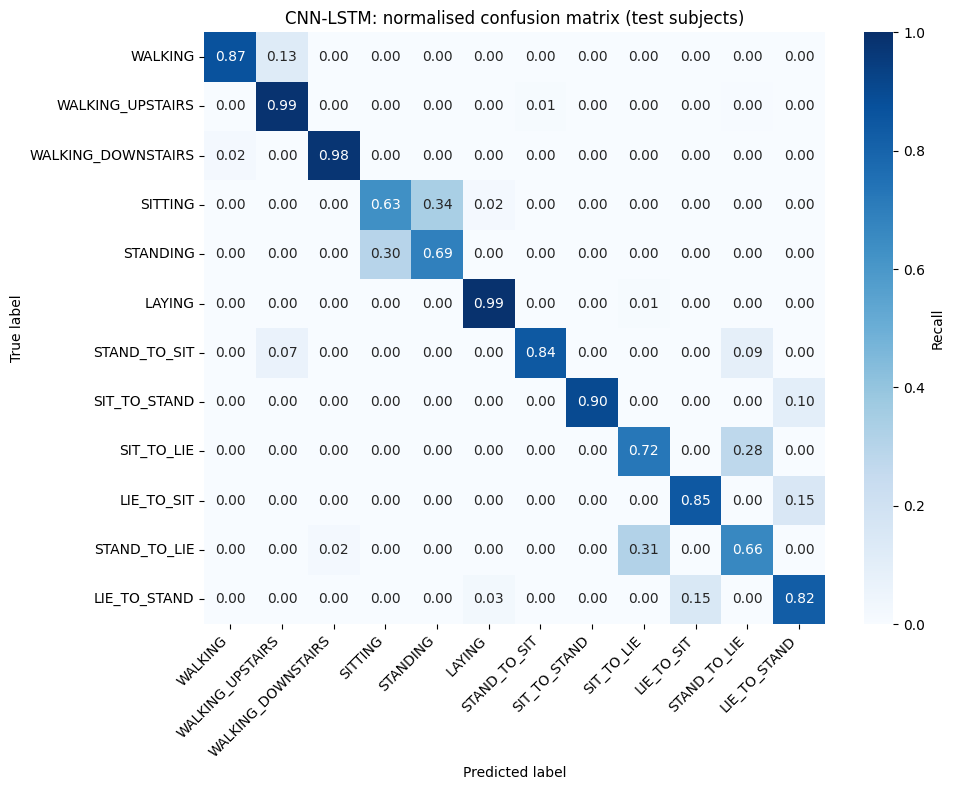

Accuracy on basic activities : 0.8508
Accuracy on transitions      : 0.7617


In [21]:
cm = confusion_matrix(y_test, y_pred, labels=np.arange(12), normalize="true")
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES, vmin=0, vmax=1, cbar_kws={"label": "Recall"})
plt.xlabel("Predicted label"); plt.ylabel("True label")
plt.title("CNN-LSTM: normalised confusion matrix (test subjects)")
plt.xticks(rotation=45, ha="right"); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "cnn_lstm_confusion.png"), dpi=150); plt.show()

# Basic activities vs transitions
basic = y_test < 6
print(f"Accuracy on basic activities : {accuracy_score(y_test[basic], y_pred[basic]):.4f}")
print(f"Accuracy on transitions      : {accuracy_score(y_test[~basic], y_pred[~basic]):.4f}")

## 13. Computational cost

In [22]:
n_params = model.count_params()
model_path = os.path.join(OUT_DIR, "cnn_lstm_final.keras")
model.save(model_path)
size_mb = os.path.getsize(model_path) / 1e6

# latency: a single window, as on a phone
single = X_test[:1]
model.predict(single, verbose=0)                       # warm-up
t0 = time.perf_counter()
for _ in range(50):
    model(single, training=False)
latency_ms = (time.perf_counter() - t0) / 50 * 1000

cost = {"parameters": int(n_params), "model_size_MB": round(size_mb, 2),
        "train_time_s": round(train_time, 1), "epochs_run": len(history.history["loss"]),
        "inference_ms_per_window": round(latency_ms, 2)}
for k, v in cost.items():
    print(f"{k:26s}: {v}")

parameters                : 234188
model_size_MB             : 2.9
train_time_s              : 62.2
epochs_run                : 23
inference_ms_per_window   : 31.8


## 14. Save results for the model comparison

The metrics go into a JSON file. Build the MLP, 1D-CNN and LSTM models the same way, with the same `split_users.npz` and `norm_stats.npz`, and each writes its own `results_<model>.json`. The final cell collects them into one comparison table.

In [23]:
results = {"model": "CNN-LSTM", **{k: round(float(v), 4) for k, v in metrics.items()}, **cost}
with open(os.path.join(OUT_DIR, "results_cnn_lstm.json"), "w") as f:
    json.dump(results, f, indent=2)

# Comparison table (picks up any results_*.json from the other models)
rows = [json.load(open(p)) for p in sorted(glob.glob(os.path.join(OUT_DIR, "results_*.json")))]
pd.DataFrame(rows).set_index("model")

,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,roc_auc_macro_ovr,parameters,model_size_MB,train_time_s,epochs_run,inference_ms_per_window
model,,,,,,,,,,,
CNN-LSTM,0.8378,0.8374,0.8289,0.8314,0.8376,0.9889,234188,2.9,62.2,23,31.8


## 15. Download your results

In [24]:
!cd /content && zip -qr cnn_lstm_outputs.zip outputs
from google.colab import files
files.download("/content/cnn_lstm_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 16. Things to try for extra marks

* **Ablation:** remove the LSTM (CNN only) or the CNN (LSTM only), train each with the same split, and show what each part adds.
* **Window length:** try 64, 128 and 256 samples. Longer windows help transitions but add latency.
* **Leave-one-subject-out CV:** the most rigorous estimate of generalisation to new users.
* **Extra channels:** add body acceleration or acceleration magnitude as channels.
* **Deployment:** `tf.lite.TFLiteConverter.from_keras_model(model)` converts the model to TFLite and shows its on-phone size.